In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [137]:
X,y_true = make_blobs(n_samples=500,centers=3,cluster_std=1,,random_state=42)

In [138]:
df = pd.DataFrame(X,columns=['feature1','feature2'])

In [139]:
df.head()

,feature1,feature2
0,-5.730354,-7.583286
1,1.942992,1.918875
2,6.829682,1.164871
3,-2.901306,7.550771
4,5.841093,1.565094


In [140]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [141]:
inertia = []
k_range = range(1,11)

In [142]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [143]:
inertia

[999.9999999999994,
 313.31642287283574,
 31.61309874414437,
 26.682762313913187,
 22.630036291422932,
 18.963373129491714,
 17.40328665433571,
 15.715303016364835,
 13.909891755351815,
 12.928886002632519]

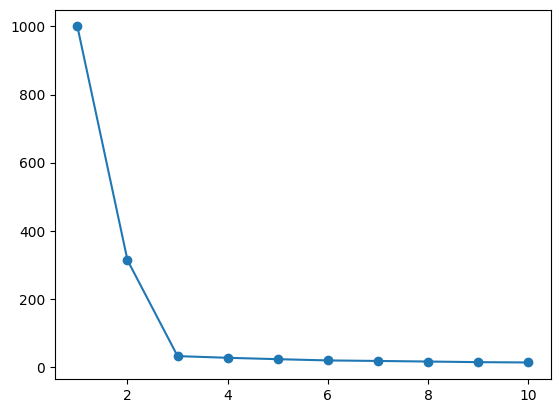

In [144]:
plt.plot(k_range,inertia,marker='o')

In [145]:
k = 3
kmeans_final = KMeans(n_clusters=k,random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [146]:
cluster_labels

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [147]:
df['cluster'] = cluster_labels

<Axes: xlabel='feature1', ylabel='feature2'>

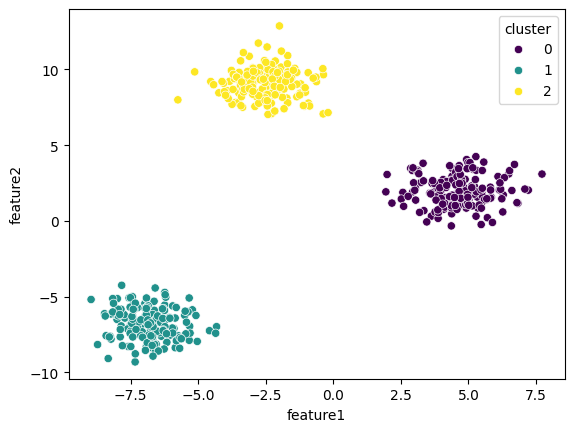

In [148]:
sns.scatterplot(x = df['feature1'],y=df['feature2'],hue = df['cluster'],palette='viridis')

In [149]:
from sklearn.datasets import make_moons

In [150]:
X,y_true = make_moons(n_samples = 500,noise = 0.05,random_state=42)

In [113]:
from sklearn.cluster import KMeans,DBSCAN

In [114]:
df = pd.DataFrame(X,columns=['feature1','feature2'])

In [115]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [116]:
kmeans = KMeans(n_clusters=2,random_state = 42)

In [117]:
cluster_labels = kmeans.fit_predict(X_scaled)

In [118]:
df['cluster'] = cluster_labels

<Axes: xlabel='feature1', ylabel='feature2'>

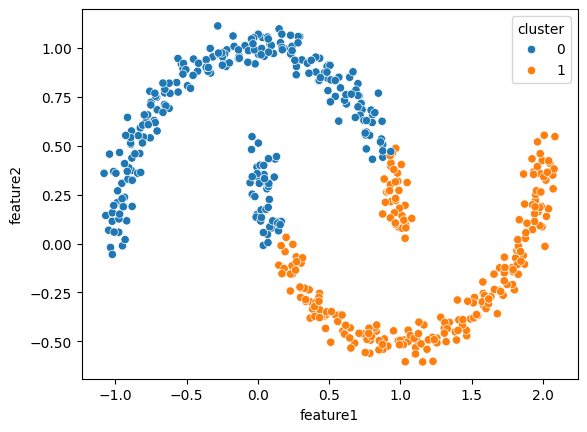

In [119]:
sns.scatterplot(x = df['feature1'],y = df['feature2'],hue = df['cluster'])

In [120]:
dbscan = DBSCAN(eps=0.3,min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [121]:
df['dbscan_clusters'] = dbscan_labels

<Axes: xlabel='feature1', ylabel='feature2'>

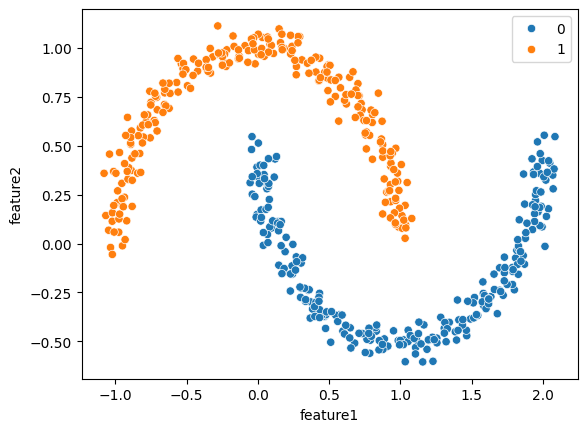

In [122]:
sns.scatterplot(x=df['feature1'],y=df['feature2'],hue = dbscan_labels)